# Анализ данных о Pokémon

Учебный анализ характеристик Pokémon: фильтрация, группировки,
сводные таблицы и простые графики.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


In [2]:
sns.set_theme(style="whitegrid")

## 1. Загрузка и проверка данных

In [3]:
pokemon = pd.read_csv("data/pokemon.csv")
print(pokemon.shape)
print(f"Повторы строк: {pokemon.duplicated().sum()}")
display(pokemon.head())
pokemon.isna().sum()

(800, 13)
Повторы строк: 0


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

## 2. Самые частые основные типы

In [4]:
type_counts = pokemon["Type 1"].value_counts()
display(type_counts.to_frame("pokemon_count"))

,pokemon_count
Type 1,
Water,112
Normal,98
Grass,70
Bug,69
Psychic,57
Fire,52
Rock,44
Electric,44
Ground,32


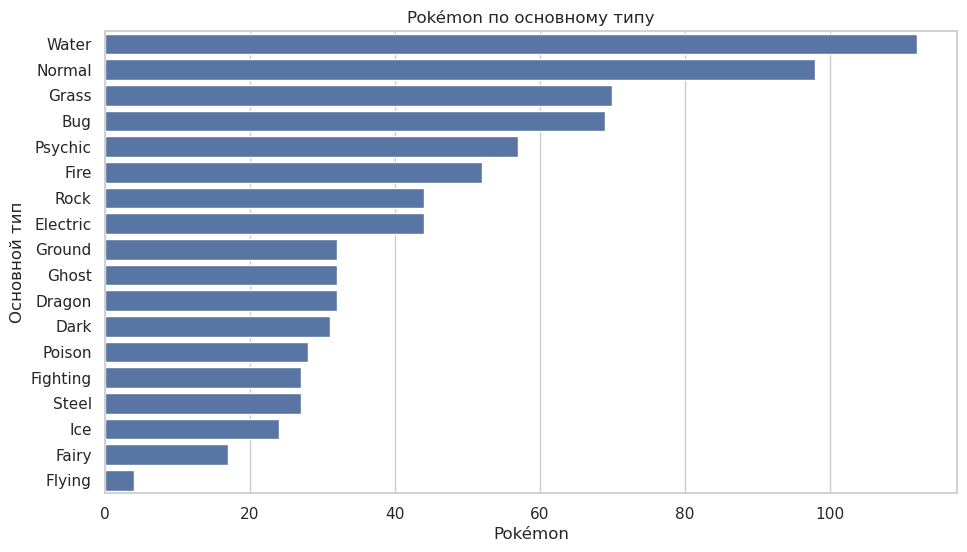

In [5]:
plt.figure(figsize=(11, 6))
ax = sns.barplot(x=type_counts.values, y=type_counts.index)
ax.set(title="Pokémon по основному типу", xlabel="Pokémon", ylabel="Основной тип")
plt.show()

## 3. Легендарные Pokémon по выбранным типам

In [6]:
selected_types = ["Water", "Normal", "Grass"]
selected_legendary = pokemon.loc[
    pokemon["Legendary"] & pokemon["Type 1"].isin(selected_types),
    ["Name", "Type 1", "Total", "Generation"],
]
selected_legendary = selected_legendary.sort_values("Total", ascending=False)

display(selected_legendary)
print(
    "Медиана Total в этой группе: "
    f"{selected_legendary['Total'].median():.1f}"
)

,Name,Type 1,Total,Generation
422,KyogrePrimal Kyogre,Water,770,3
552,Arceus,Normal,720,4
541,Palkia,Water,680,4
543,Regigigas,Normal,670,4
421,Kyogre,Water,670,3
551,ShayminSky Forme,Grass,600,4
550,ShayminLand Forme,Grass,600,4
264,Suicune,Water,580,2
701,Virizion,Grass,580,5


Медиана Total в этой группе: 670.0


## 4. Легендарные и обычные Pokémon

In [7]:
legendary_groups = pokemon.groupby("Legendary")
power_summary = legendary_groups["Name"].size().to_frame("pokemon_count")
power_summary["median_total"] = legendary_groups["Total"].median()
power_summary["mean_attack"] = legendary_groups["Attack"].mean()
power_summary["mean_defense"] = legendary_groups["Defense"].mean()
power_summary["mean_speed"] = legendary_groups["Speed"].mean()
power_summary = power_summary.rename(index={False: "Обычные", True: "Легендарный"})
power_summary = power_summary.round(1)

display(power_summary)

,pokemon_count,median_total,mean_attack,mean_defense,mean_speed
Legendary,,,,,
Обычные,735,425.0,75.7,71.6,65.5
Легендарный,65,600.0,116.7,99.7,100.2


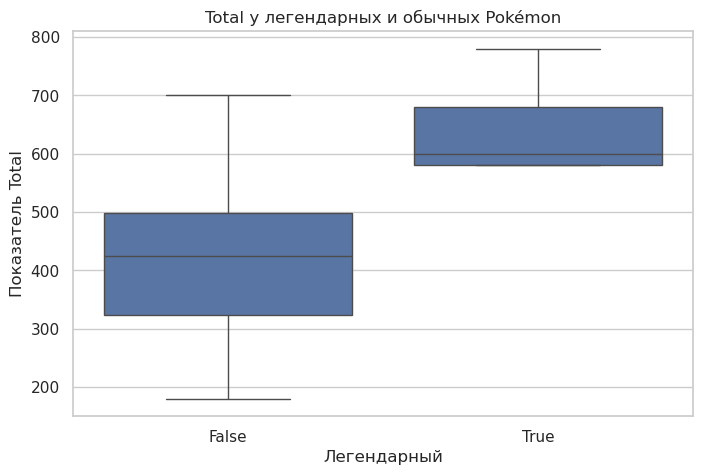

In [8]:
plt.figure(figsize=(8, 5))
ax = sns.boxplot(data=pokemon, x="Legendary", y="Total")
ax.set(
    title="Total у легендарных и обычных Pokémon",
    xlabel="Легендарный",
    ylabel="Показатель Total",
)
plt.show()

## 5. Самые сильные Pokémon

In [9]:
strongest = pokemon.nlargest(10, "Total")[
    ["Name", "Type 1", "Type 2", "Total", "Generation", "Legendary"]
]
display(strongest)

,Name,Type 1,Type 2,Total,Generation,Legendary
163,MewtwoMega Mewtwo X,Psychic,Fighting,780,1,True
164,MewtwoMega Mewtwo Y,Psychic,NaN,780,1,True
426,RayquazaMega Rayquaza,Dragon,Flying,780,3,True
422,KyogrePrimal Kyogre,Water,NaN,770,3,True
424,GroudonPrimal Groudon,Ground,Fire,770,3,True
552,Arceus,Normal,NaN,720,4,True
268,TyranitarMega Tyranitar,Rock,Dark,700,2,False
409,SalamenceMega Salamence,Dragon,Flying,700,3,False
413,MetagrossMega Metagross,Steel,Psychic,700,3,False
418,LatiasMega Latias,Dragon,Psychic,700,3,True


## 6. Выводы

In [10]:
most_common_type = type_counts.index[0]
regular_median = power_summary.loc["Обычные", "median_total"]
legendary_median = power_summary.loc["Легендарный", "median_total"]

print(f"Самый частый основной тип: {most_common_type}")
print(f"Медиана Total обычных Pokémon: {regular_median:.0f}")
print(f"Медиана Total легендарных Pokémon: {legendary_median:.0f}")
print(
    "Легендарных Pokémon мало, но их типичный показатель Total заметно выше "
    "показателя обычных Pokémon."
)

Самый частый основной тип: Water
Медиана Total обычных Pokémon: 425
Медиана Total легендарных Pokémon: 600
Легендарных Pokémon мало, но их типичный показатель Total заметно выше показателя обычных Pokémon.
